<a href="https://colab.research.google.com/github/Jhairo18/Mantenimiento-predictivo-AI4I-2020-/blob/main/mantenimientoy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving mantenimiento.csv to mantenimiento (1).csv


In [ ]:
import pandas as pd

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,roc_curve,roc_auc_score,accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential



# **Lectura de datos y exploracion**



In [ ]:
df = pd.read_csv("mantenimiento.csv")
print(df.head())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Target Failure Type  
0                    1551         42.8                0       0   No Failure  
1                    1408         46.3                3       0   No Failure  
2                    1498         49.4                5       0   No Failure  
3                    1433         39.5                7       0   No Failure  
4                    1408         40.0                9       0   No Failure  


In [ ]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Target', 'Failure Type'],
      dtype='object')

In [ ]:
df.rename({"Air temperature [K]":"Air Temp[K]","Process temperature [K]":"Proc Temp[K]"})
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


Observamos si no hay datos faltantes y saber el tipo de dato de cacad columna

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [ ]:
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Target,0
Failure Type,0


In [ ]:
print(df["Target"].value_counts())
print("------------------")
print(df["Failure Type"].value_counts())

Target
0    9661
1     339
Name: count, dtype: int64
------------------
Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64


In [ ]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Target', 'Failure Type'],
      dtype='object')

In [ ]:
df.drop(["UDI","Product ID",'Failure Type'],axis="columns",inplace=True)

In [ ]:
df

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0
...,...,...,...,...,...,...,...
9995,M,298.8,308.4,1604,29.5,14,0
9996,H,298.9,308.4,1632,31.8,17,0
9997,M,299.0,308.6,1645,33.4,22,0
9998,H,299.0,308.7,1408,48.5,25,0


# **Preprocesamiento de la data**

In [ ]:
x = df.iloc[:,:-1]
x

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9
...,...,...,...,...,...,...
9995,M,298.8,308.4,1604,29.5,14
9996,H,298.9,308.4,1632,31.8,17
9997,M,299.0,308.6,1645,33.4,22
9998,H,299.0,308.7,1408,48.5,25


In [ ]:
y = df.iloc[:,-1]
y

,Target
0,0
1,0
2,0
3,0
4,0
...,...
9995,0
9996,0
9997,0
9998,0


In [ ]:
from sklearn.model_selection import train_test_split
x_trvl, x_ts, y_trvl, y_ts = train_test_split(x,y,
                                              test_size=0.2,
                                              random_state=42,
                                              stratify=y)

print("Tamaño del set de entrenamiento/validación",x_trvl.shape,y_trvl.shape)
print("Tamaño del set de prueba",x_ts.shape,y_ts.shape)
print("Proporcion de categorias en el set de entrenamiento/validacion")
print(y_trvl.value_counts())
print("Proporcion de categorias en el set de prueba")
print(y_ts.value_counts())

Tamaño del set de entrenamiento/validación (8000, 6) (8000,)
Tamaño del set de prueba (2000, 6) (2000,)
Proporcion de categorias en el set de entrenamiento/validacion
Target
0    7729
1     271
Name: count, dtype: int64
Proporcion de categorias en el set de prueba
Target
0    1932
1      68
Name: count, dtype: int64


Como hay variable categorica en tpe haremos OrdinalEncoder

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
x_encoder = OrdinalEncoder()
types = ["L","M","H"]
x_trvl["Type"] = x_encoder.fit_transform(x_trvl[["Type"]])
x_trvl


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
4058,2.0,302.0,310.9,1456,47.2,54
1221,2.0,297.0,308.3,1399,46.4,132
6895,2.0,301.0,311.6,1357,45.6,137
9863,1.0,298.9,309.8,1411,56.3,84
8711,1.0,297.1,308.5,1733,28.7,50
...,...,...,...,...,...,...
980,1.0,296.1,306.7,1409,42.8,134
4266,1.0,302.7,311.1,1440,39.5,146
7772,0.0,300.3,311.5,1464,41.0,29
5780,1.0,301.7,311.2,1517,42.4,113


In [ ]:
x_ts["Type"] = x_encoder.fit_transform(x_ts[["Type"]])

#**Entrenamiento de modelo**

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

log_reg = LogisticRegression(
    class_weight = "balanced",
    max_iter = 500
)

# Creando particiones
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Realizando k-fold validation
score_lr_cv = cross_val_score(log_reg, x_trvl, Y, cv=skf, scoring="accuracy")

print("Puntajes de validacion cruzada para Regresion Logistica", score_lr_cv)
print("Accuracy promedio para Regresion Logistica", score_lr_cv.mean())
print("Desviacion de puntajes para Regresion Logistica", score_lr_cv.std())


log_reg.fit(x_trvl,Y)
y_pred_lr = log_reg.predict(x_ts)
y_pred_prob_lr = log_reg.predict_proba(x_ts)

Puntajes de validacion cruzada para Regresion Logistica [0.809375 0.829375 0.818125 0.831875 0.816875]
Accuracy promedio para Regresion Logistica 0.821125
Desviacion de puntajes para Regresion Logistica 0.008351646544245047


In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier

arbol = DecisionTreeClassifier(max_depth=10)
# Creando particiones
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Realizando k-fold validation
score = cross_val_score(arbol, x_trvl,Y,cv=skf,scoring="accuracy")

print("Puntajes de validacion cruzada", score)
print("Accuracy promedio", score.mean())
print("Desviacion de puntajes",score.std())

arbol = DecisionTreeClassifier(max_depth=10)
arbol.fit(x_trvl,Y)
y_pred_ar = arbol.predict(x_ts)
y_pred_prob_ar = arbol.predict_proba(x_ts)

Puntajes de validacion cruzada [0.98875  0.98     0.9825   0.980625 0.980625]
Accuracy promedio 0.9824999999999999
Desviacion de puntajes 0.003235544776386213


In [ ]:
from sklearn.ensemble import RandomForestClassifier
bosque = RandomForestClassifier(oob_score=True)
bosque.fit(x_trvl,Y)
# Desempeño con el set de validación (muestras "out-of-bag")
vl_score = bosque.oob_score_
print(f'Exactitud validación (OOB): {100*vl_score:.1f}%')
# Desempeño con el set de prueba
ts_score = bosque.score(x_ts, y_ts)
print(f'Exactitud prueba: {100*ts_score:.1f}%')

y_pred_rf = bosque.predict(x_ts)
y_pred_prob_rf = bosque.predict_proba(x_ts)

Exactitud validación (OOB): 98.4%
Exactitud prueba: 98.5%


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
model = Sequential([
    Dense(16,activation="relu",input_shape=(x_trvl.shape[1],)),
    Dense(16,activation="relu"),
    Dense(1,activation="sigmoid")
]
    )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])
history = model.fit(
      x_trvl,Y,
      validation_split=0.2,
      epochs=50,
      batch_size=128,
      verbose = 1

)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5362 - loss: 21.0780 - val_accuracy: 0.9656 - val_loss: 2.0551
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9673 - loss: 1.4993 - val_accuracy: 0.9600 - val_loss: 0.8157
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9567 - loss: 0.8388 - val_accuracy: 0.9575 - val_loss: 0.6129
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9564 - loss: 0.5423 - val_accuracy: 0.9531 - val_loss: 0.4852
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9529 - loss: 0.4164 - val_accuracy: 0.9544 - val_loss: 0.3837
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9506 - loss: 0.3593 - val_accuracy: 0.9444 - val_loss: 0.2957
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9537 - loss: 0.2637 - val_accuracy: 0.9656 - val_loss: 0.2562
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9586 - loss: 0.2657 - val_accuracy: 0.9663 - val_loss

In [ ]:
loss, acc = model.evaluate(x_ts,np.array(y_ts))
print(f"Exactitud de prueba {100*acc:.2f}")
y_pred_prob_dnn = model.predict(x_ts)
y_pred_dnn = (y_pred_prob_dnn>0.5).astype(int).flatten()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9626 - loss: 0.1282
Exactitud de prueba 96.60
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
def report_model(name,y_true,y_pred):
  print(f"Reporte de {name}")
  print(classification_report(y_true,y_pred))
  cm = confusion_matrix(y_true,y_pred)
  fig, ax = plt.subplots(figsize=(14, 10))
  disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["No Failure","Failure"])
  disp.plot(ax=ax)
  plt.show()

Reporte de Regresion Logistica
              precision    recall  f1-score   support

           0       0.99      0.82      0.90      1932
           1       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000



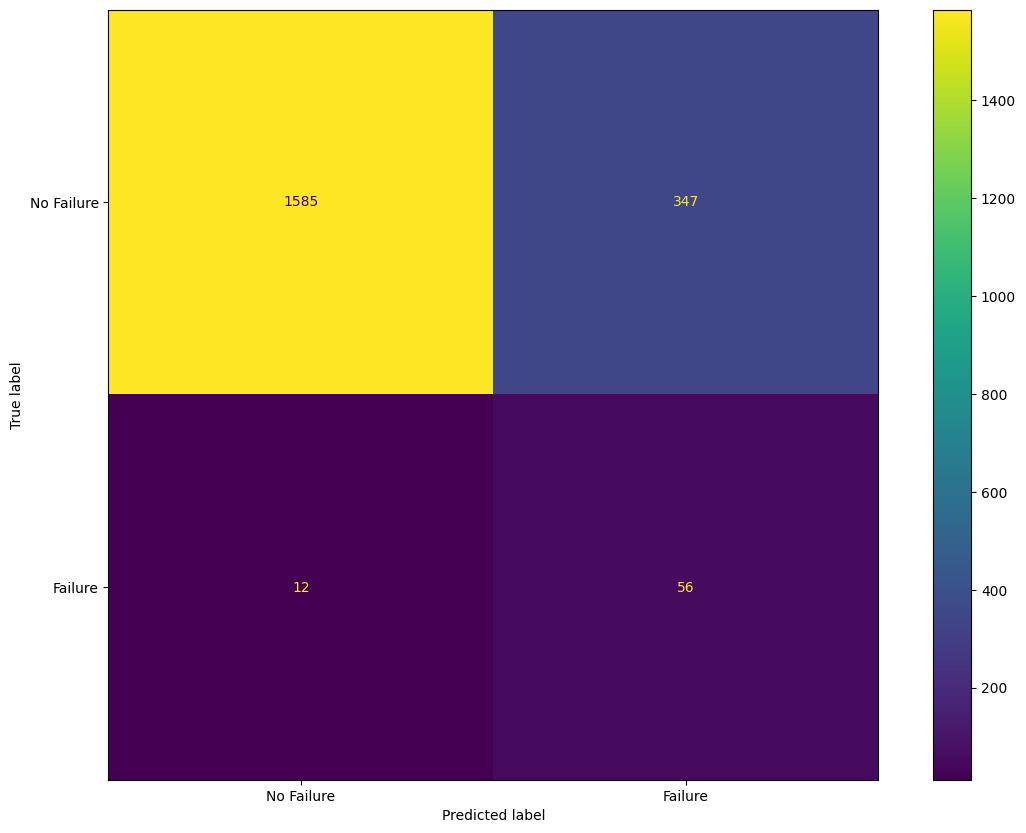

Reporte de Arbol de decision
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.80      0.76      0.78        68

    accuracy                           0.99      2000
   macro avg       0.90      0.88      0.89      2000
weighted avg       0.99      0.99      0.99      2000



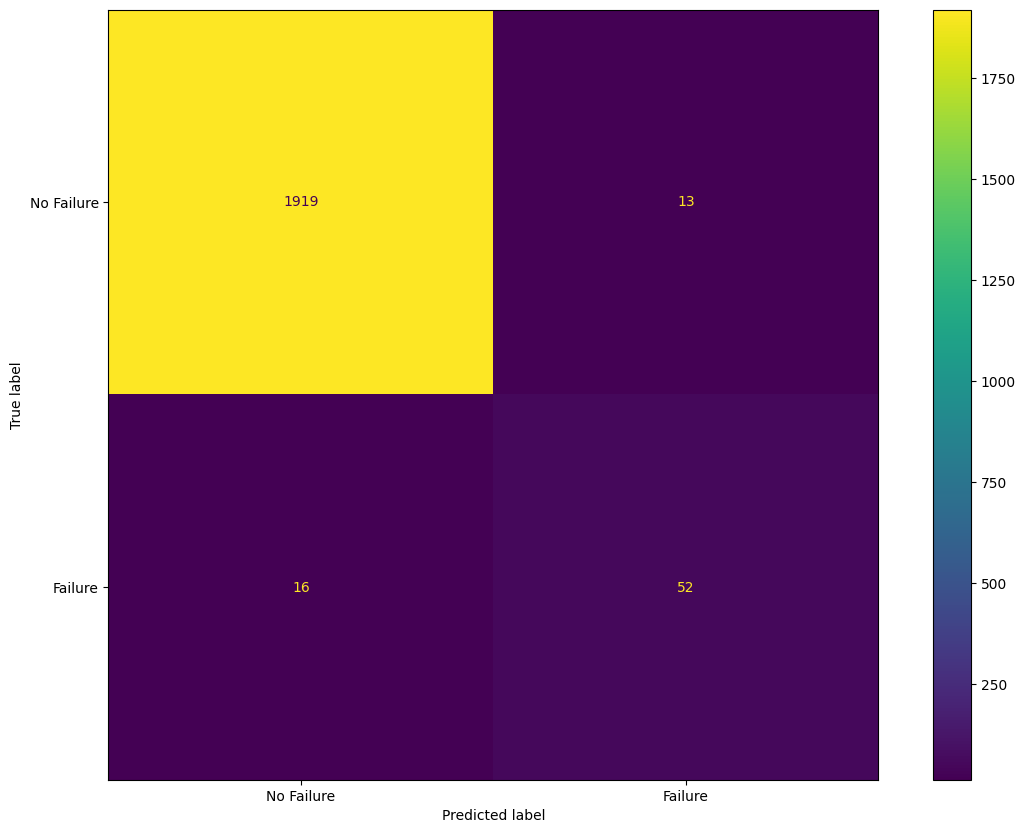

Reporte de Random Forest
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.86      0.65      0.74        68

    accuracy                           0.98      2000
   macro avg       0.93      0.82      0.87      2000
weighted avg       0.98      0.98      0.98      2000



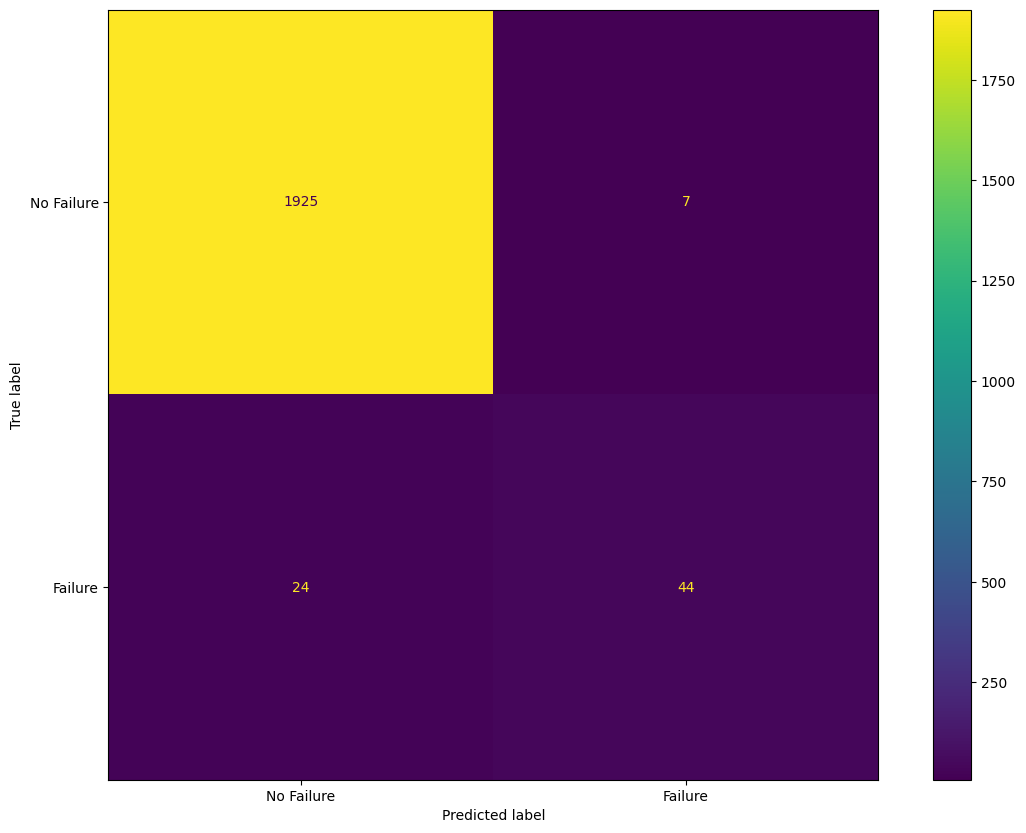

Reporte de DNN
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.50      0.03      0.06        68

    accuracy                           0.97      2000
   macro avg       0.73      0.51      0.52      2000
weighted avg       0.95      0.97      0.95      2000



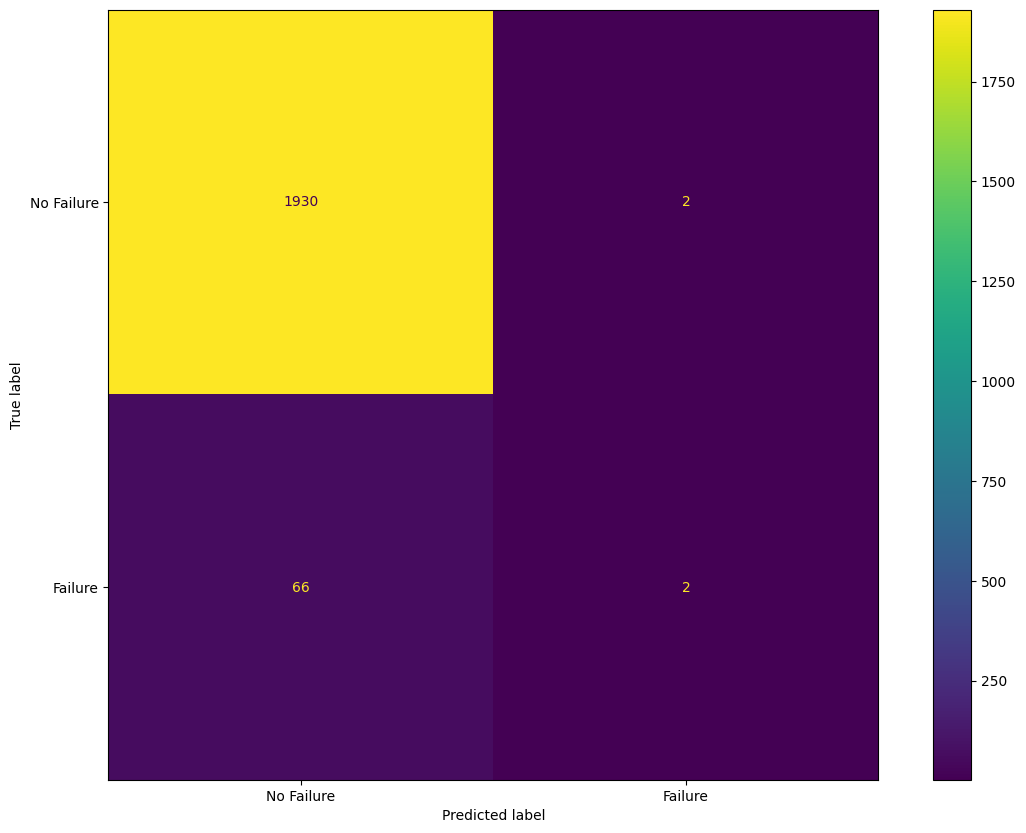


AUC Scores:
 LR=0.906
 AR=0.877
 RF=0.970
 DNN=0.933

Accuracy:
 LR=0.821
 AR=0.986
 RF=0.985
 DNN=0.966


In [ ]:
report_model("Regresion Logistica",y_ts,y_pred_lr)
report_model("Arbol de decision",y_ts,y_pred_ar)
report_model("Random Forest",y_ts,y_pred_rf)
report_model("DNN",y_ts,y_pred_dnn)

auc_lr = roc_auc_score(y_ts,y_pred_prob_lr[:,1])
auc_ar = roc_auc_score(y_ts,y_pred_prob_ar[:,1])
auc_rf = roc_auc_score(y_ts,y_pred_prob_rf[:,1])
auc_dnn = roc_auc_score(y_ts,y_pred_prob_dnn)

acc_lr = accuracy_score(y_ts,y_pred_lr)
acc_ar = accuracy_score(y_ts,y_pred_ar)
acc_rf = accuracy_score(y_ts,y_pred_rf)
acc_dnn = accuracy_score(y_ts,y_pred_dnn)

print(f"\nAUC Scores:\n LR={auc_lr:.3f}\n AR={auc_ar:.3f}\n RF={auc_rf:.3f}\n DNN={auc_dnn:.3f}")
print(f"\nAccuracy:\n LR={acc_lr:.3f}\n AR={acc_ar:.3f}\n RF={acc_rf:.3f}\n DNN={acc_dnn:.3f}")


# **Evaluación del modelo**

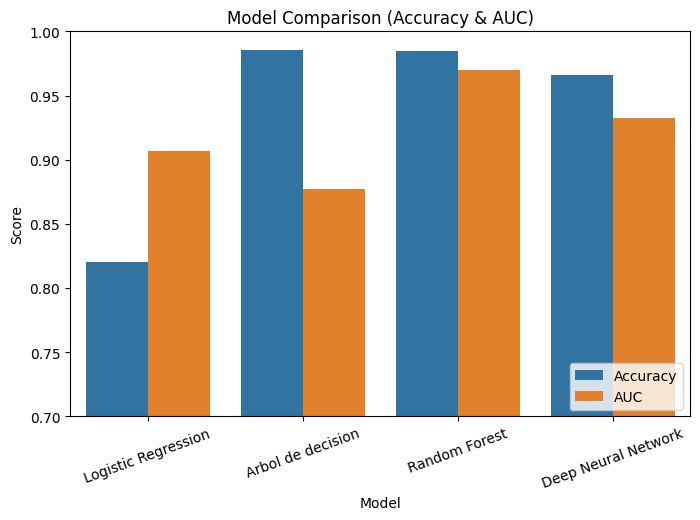

In [ ]:
results = pd.DataFrame({
    'Model': ['Logistic Regression','Arbol de decision', 'Random Forest', 'Deep Neural Network'],
    'Accuracy': [acc_lr,acc_ar, acc_rf, acc_dnn],
    'AUC': [auc_lr, auc_ar, auc_rf, auc_dnn]
})

plt.figure(figsize=(8, 5))
sns.barplot(
    data=results.melt(id_vars='Model', var_name='Metric', value_name='Score'),
    x='Model', y='Score', hue='Metric'
)
plt.title("Model Comparison (Accuracy & AUC)")
plt.ylim(0.7, 1.0)
plt.legend(loc='lower right')
plt.xticks(rotation=20)
plt.show()